<a href="https://colab.research.google.com/github/anddennn/IAT360_YogaPoseDetection_CVProject/blob/main/ComputerVisionProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><h1> <b> Pose Estimation Using YOLO <b> </h1></center>




Importing required Libraries

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import cv2
import seaborn as sns
import glob
import xml.etree.ElementTree as ET
from PIL import Image
import os
import shutil

# Dataset Description






[insert dataset description here]


# Data Preprocessing

For preprocessing:
[insert preprocessing steps here]


## Heirarchy of Folders correction

Defining paths to train and test folders.

In [4]:
train_dir = '/content/drive/MyDrive/Dataset/train'
valid_dir = '/content/drive/MyDrive/Dataset/valid'



The train and test folders have all the images and labels together.

But for YOLO, the directories should be in:

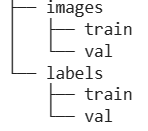


Making directories according to above struture of folders

In [5]:
#import os
#run it once for making directories

#os.makedirs('/content/drive/MyDrive/Tutorials/Datasets/FRUIT DATA/Final_data')

os.makedirs('/content/drive/MyDrive/Dataset/images')
os.makedirs('/content/drive/MyDrive/Dataset/labels')
os.makedirs('/content/drive/MyDrive/Dataset/images/train')
os.makedirs('/content/drive/MyDrive/Dataset/images/val')
os.makedirs('/content/drive/MyDrive/Dataset/labels/train')
os.makedirs('/content/drive/MyDrive/Dataset/labels/val')

In [6]:
#set the paths to labels and images directory
label_dir= "/content/drive/MyDrive/Dataset/labels"
image_dir="/content/drive/MyDrive/Dataset/images"

Copy XML files and jpg files from the train folder to the folders created.

In [7]:
#import shutil

# change val to test #############

#run it once for copying!
for root, dirs, files in os.walk(train_dir):
    for file in files:
        if file.endswith(".txt"):
            shutil.copy(os.path.join(root, file), os.path.join(label_dir, "train"))
        if file.endswith(".jpg"):
            image = Image.open(os.path.join(root, file))
            image = image.convert("RGB")
            new_filename = os.path.splitext(file)[0] + ".jpg"
            image.save(os.path.join(image_dir,"train", new_filename), "JPEG")
            shutil.copy(os.path.join(root, file), os.path.join(image_dir, "train"))


#Copy XML files and jpg files from the test folder to the folders created.
for root, dirs, files in os.walk(valid_dir):
    for file in files:
        if file.endswith(".txt"):
            shutil.copy(os.path.join(root, file), os.path.join(label_dir, "val"))
        if file.endswith(".jpg"):
            image = Image.open(os.path.join(root, file))
            image = image.convert("RGB")
            new_filename = os.path.splitext(file)[0] + ".jpg"
            image.save(os.path.join(image_dir,"val", new_filename), "JPEG")
            shutil.copy(os.path.join(root, file), os.path.join(image_dir, "val"))

Visualizing somme pictures from the dataset

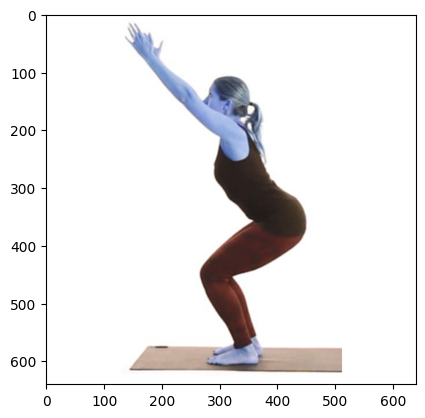

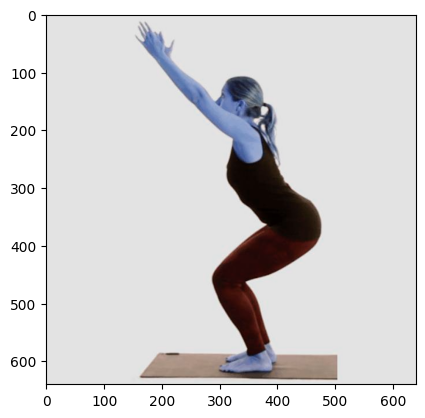

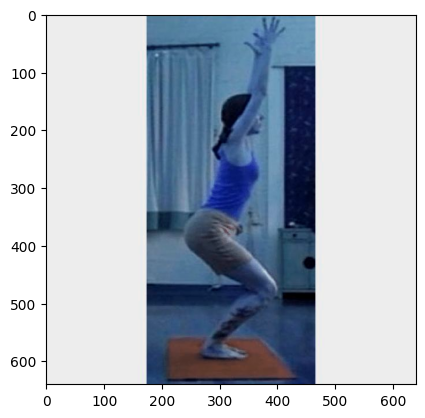

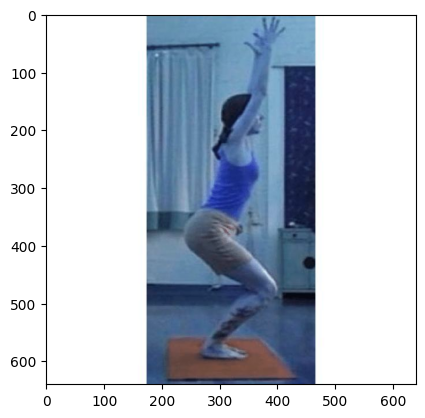

In [8]:
#visualize first four sample images from train data
for idx, image in enumerate(os.listdir(os.path.join(image_dir, "train"))):
    img = cv2.imread(os.path.join(image_dir,"train", image), 1)
    plt.imshow(img)
    plt.show()

    if idx == 3:
        break

## Checking Missing Files [do we need this?]

Checking the folders if every image file has a corresponding label file


(We will copy the code, we already used in previous turorial after updating)

In [ ]:
#The lists of all the images and labels for train and validation set:
train_images=glob.glob(os.path.join(image_dir, "train",'*.jpg'))
train_labels=glob.glob(os.path.join(label_dir, "train",'*.txt'))
val_images=glob.glob(os.path.join(image_dir, "val",'*.jpg'))
val_labels=glob.glob(os.path.join(label_dir, "val",'*.txt'))
#print(val_labels)

# Get the list of filenames without extensions
image_files_train = {file.split("/")[-1].split(".")[0] for file in train_images}
label_files_train = {file.split("/")[-1].split(".")[0] for file in train_labels}

image_files_val = {file.split("/")[-1].split(".")[0] for file in val_images}
label_files_val = {file.split("/")[-1].split(".")[0] for file in val_labels}
#print(image_files_val)



In [ ]:
print(len(image_files_val), "  =  ", len(label_files_val))

56   =   56


In [ ]:
# Find extra files in each folder

#TRAINING DATA
extra_images_train = image_files_train - label_files_train
extra_labels_train = label_files_train - image_files_train

# Output the results
print(f"Training Extra images (without corresponding labels): {extra_images_train}")
print(f"Training Extra labels (without corresponding images): {extra_labels_train}")


#VALIDATION DATA
extra_images_val = image_files_val - label_files_val
extra_labels_val = label_files_val - image_files_val

# Output the results
print(f"Validation Extra images (without corresponding labels): {extra_images_val}")
print(f"Validation Extra labels (without corresponding images): {extra_labels_val}")

Training Extra images (without corresponding labels): set()
Training Extra labels (without corresponding images): set()
Validation Extra images (without corresponding labels): set()
Validation Extra labels (without corresponding images): set()


Make sure that the above info is correct by chceking the data manually.

Now removing from the dataset:

In [ ]:
for file in extra_images_train:
     os.remove(os.path.join(image_dir, "train", file + '.jpg')) # or '.png' depending on your image format

for file in extra_images_val:
     os.remove(os.path.join(image_dir, "val", file + '.jpg'))

Now run the above cells again to find if all the missing data is deleted.

# Custom pose estimation using YOLO

First install and import

In [9]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.223 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.2/112.6 GB disk)


In [10]:
from ultralytics import YOLO

## Training YOLO

We are going to select small pretrained (on COCO dataset) model of YOLOv8

In [11]:
model = YOLO("yolo11n-pose.pt") # pretrained model

The detailed architecture of the model can be seen from:


In [12]:
model

YOLO(
  (model): PoseModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats

In [31]:
%%writefile config.yaml
path: /content/drive/MyDrive/Dataset
train: /content/drive/MyDrive/Dataset/images/train
#test: (test dataset folder path)
val: /content/drive/MyDrive/Dataset/images/val

# Task type
task: pose

# Classes
names:
  0: chairPose
  1: corpsePose
  2: downwardDog
  3: mountainPose
  4: seatedDownwardBend
  5: treePose

# Keypoint configuration
kpt_shape: [18, 3]  # 18 keypoints, each with (x, y, visibility)

# Keypoint Connections (Skeleton) Right now the skeleton doesn't show
skeleton:
  - [0, 1]  # Nose to Neck
  - [0, 2]  # Nose to Left-Eye
  - [0, 3]  # Nose to Right-Eye
  - [2, 4]  # Left-Eye to Left-Ear
  - [3, 5]  # Right-Eye to Right-Ear
  - [1, 6]  # Neck to Left-Shoulder
  - [1, 7]  # Neck to Right-Shoulder
  - [6, 8]  # Left-Shoulder to Left-Elbow
  - [8, 10] # Left-Elbow to Left-Wrist
  - [7, 9]  # Right-Shoulder to Right-Elbow
  - [9, 11] # Right-Elbow to Right-Wrist
  - [6, 12] # Left-Shoulder to Left-Hip
  - [7, 13] # Right-Shoulder to Right-Hip
  - [12, 13] # Left-Hip to Right-Hip
  - [12, 14] # Left-Hip to Left-Knee
  - [14, 16] # Left-Knee to Left-Ankle
  - [13, 15] # Right-Hip to Right-Knee
  - [15, 17] # Right-Knee to Right-Ankle

# Keypoint Colors (B, G, R format)
kpt_colors:
  - [255, 0, 0]   # Nose (Red)
  - [0, 255, 0]   # Neck (Green)
  - [0, 0, 255]   # Left-Eye (Blue)
  - [255, 255, 0] # Right-Eye (Yellow)
  - [0, 255, 255] # Left-Ear (Cyan)
  - [255, 0, 255] # Right-Ear (Magenta)
  - [128, 0, 0]   # Left-Shoulder (Dark Red)
  - [0, 128, 0]   # Right-Shoulder (Dark Green)
  - [0, 0, 128]   # Left-Elbow (Dark Blue)
  - [128, 128, 0] # Right-Elbow (Olive)
  - [0, 128, 128] # Left-Wrist (Teal)
  - [128, 0, 128] # Right-Wrist (Purple)
  - [64, 64, 64]  # Left-Hip (Gray)
  - [192, 192, 192] # Right-Hip (Light Gray)
  - [255, 128, 0] # Left-Knee (Orange)
  - [0, 128, 255] # Right-Knee (Light Blue)
  - [128, 255, 0] # Left-Ankle (Lime Green)
  - [255, 0, 128] # Right-Ankle (Pink)

# (Optional but recommended for pose augmentation/flipping)
# flip_idx: [0, 2, 1, 4, 3, 6, 5, 8, 7, 10, 9, 12, 11, 14, 13, 16, 15]

# (Optional: Human-readable keypoint names for reference)
kpt_names:
  - Nose
  - Neck
  - Left-Eye
  - Right-Eye
  - Left-Ear
  - Right-Ear
  - Left-Shoulder
  - Right-Shoulder
  - Left-Elbow
  - Right-Elbow
  - Left-Wrist
  - Right-Wrist
  - Left-Hip
  - Right-Hip
  - Left-Knee
  - Right-Knee
  - Left-Ankle
  - Right-Ankle

Overwriting config.yaml


Please look at [Yolo train Docs](https://docs.ultralytics.com/modes/train/#train-settings) for hyperparameters for model tuning and configuration, e.g. lr0, imgsz, model etc.

In [32]:
!rm -f /content/drive/MyDrive/Dataset/labels/train.cache
!rm -f /content/drive/MyDrive/Dataset/labels/val.cache

In [33]:
model.train(data="config.yaml", epochs=5, imgsz=640)

Ultralytics 8.3.223 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=config.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/pose/train/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots

ultralytics.utils.metrics.PoseMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f420c1e28a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(P)', 'F1-Confidence(P)', 'Precision-Confidence(P)', 'Recall-Confidence(P)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033

## Evaluation Metrics

[This](https://docs.ultralytics.com/guides/yolo-performance-metrics/) is a very good detailed explanation of different perfromance metrics in YOLO.

**Choosing the Right Metrics**

Choosing the right metrics to evaluate often depends on the specific application.

- mAP: Suitable for a broad assessment of model performance.

- IoU: Essential when precise object location is crucial.

- Precision: Important when minimizing false detections is a priority.

- Recall: Vital when it's important to detect every instance of an object.

- F1 Score: Useful when a balance between precision and recall is needed.


In [34]:
metrics = model.val()  # no arguments needed, dataset and settings remembered
metrics.box.map    # map50-95
metrics.box.map50  # map50
metrics.box.map75  # map75
metrics.box.maps   # a list contains map50-95 of each category
metrics.box.mp    # P
metrics.box.mr    # R

Ultralytics 8.3.223 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n-pose summary (fused): 109 layers, 2,889,016 parameters, 0 gradients, 7.5 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 11.8±6.2 MB/s, size: 24.6 KB)
val: Scanning /content/drive/MyDrive/Dataset/labels/val.cache... 56 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 56/56 83.7Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.2it/s 3.5s
                   all         56         56      0.928      0.984      0.995      0.819      0.122      0.114       0.06    0.00745
             chairPose         11         11          1      0.928      0.995      0.781          0          0     0.0065    0.00065
            corpsePose         13         13      0.944          1      0.995      0.664          0          0   0.000752   7.52e-05
           downwardDog         11       

np.float64(0.984178796568877)

Showing confusion matrix, that is already stored in detect/train folder

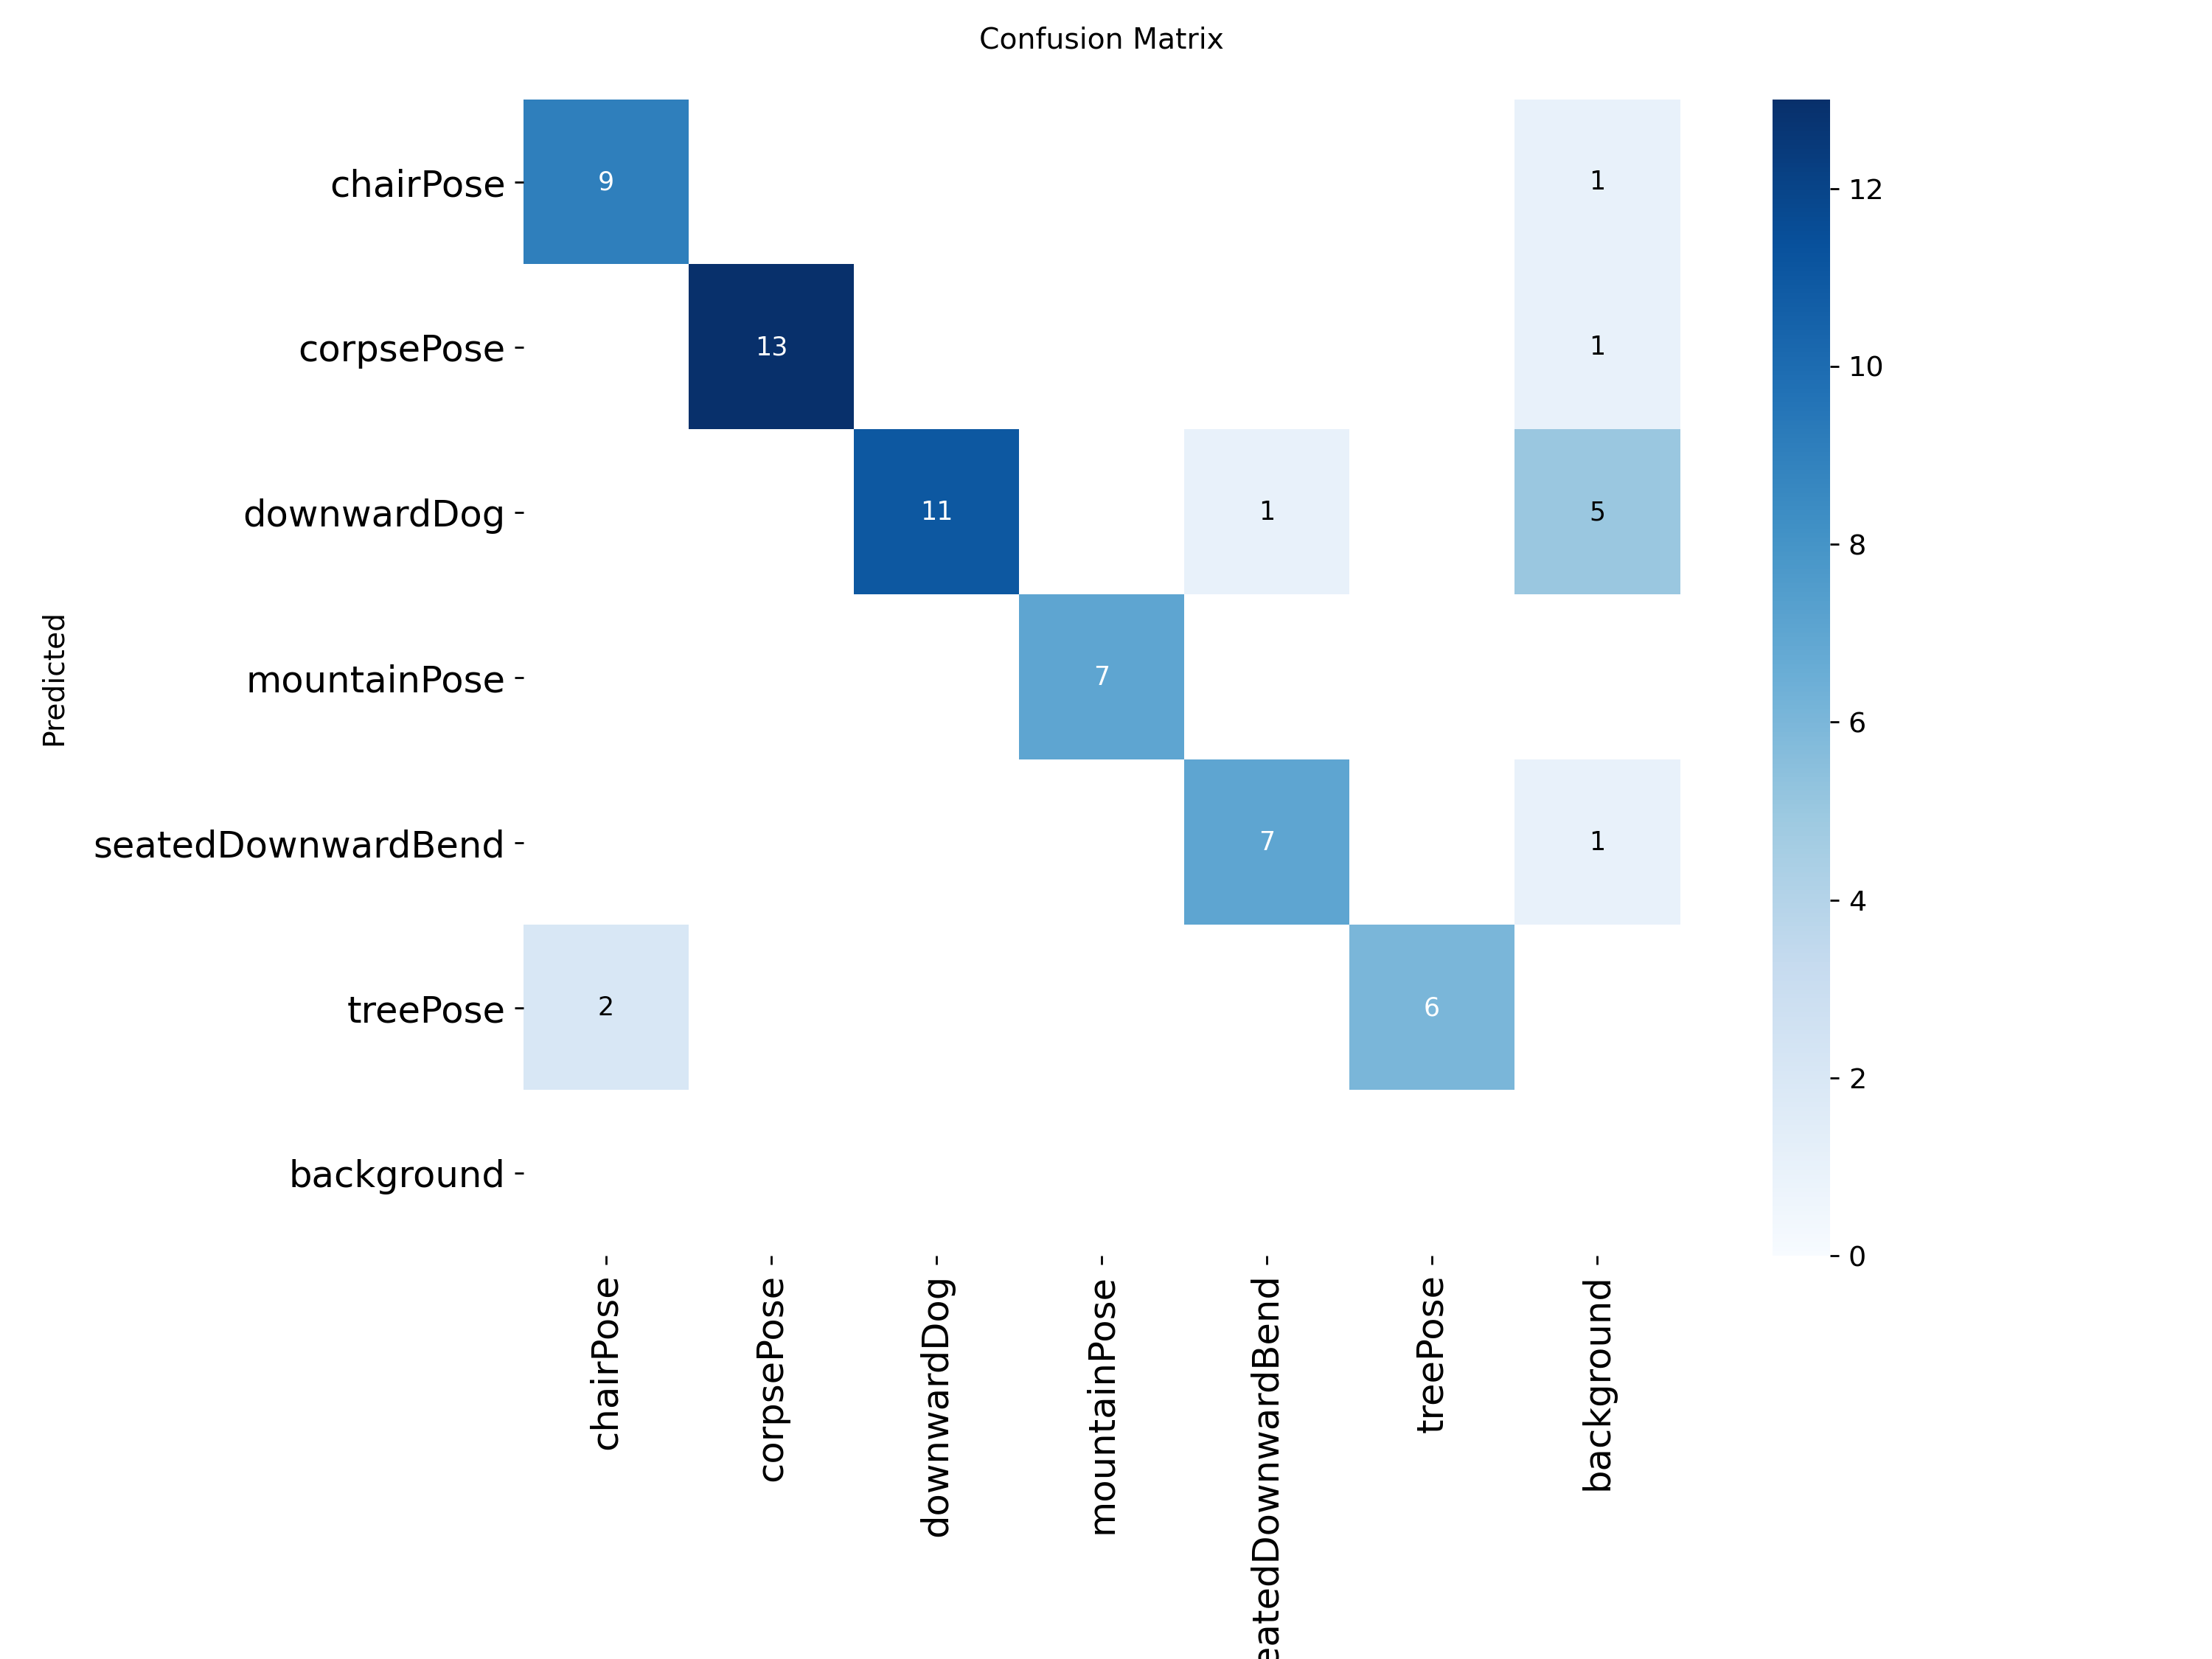

In [18]:
%matplotlib inline
from PIL import Image

Image.open('/content/runs/pose/train/confusion_matrix.png')

##Prediction

In [35]:
# Depending on training change path to find the 'best.pt' I did it twice here so it's in train2 but change if necessary

model = YOLO("/content/runs/pose/train2/weights/best.pt")  # load a custom model

# Predict with the model with any image from internet?
results = model('/content/drive/MyDrive/Dataset/valid/images/chairPose_0_1_32_jpg.rf.92d982a3b366833b091081555066d38a.jpg', save=True)


image 1/1 /content/drive/MyDrive/Dataset/valid/images/chairPose_0_1_32_jpg.rf.92d982a3b366833b091081555066d38a.jpg: 640x640 1 chairPose, 10.4ms
Speed: 2.1ms preprocess, 10.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/pose/predict3


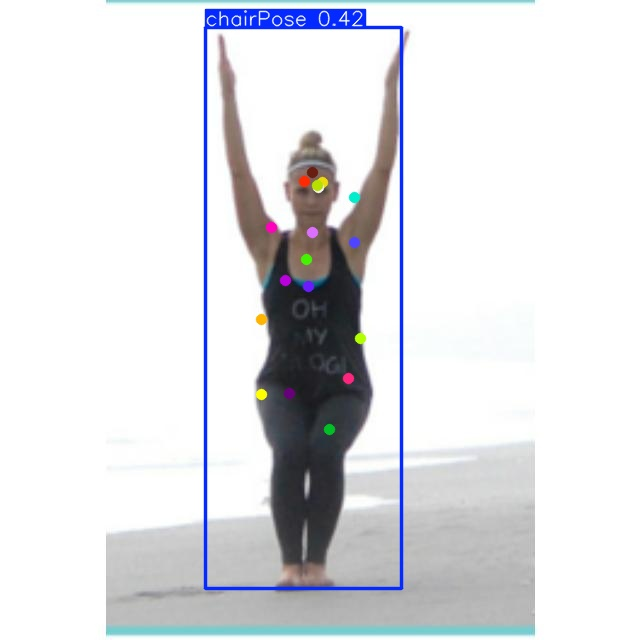

In [36]:
# SHOW THE IMAGE STORED
%matplotlib inline
from PIL import Image

Image.open('/content/runs/pose/predict3/chairPose_0_1_32_jpg.rf.92d982a3b366833b091081555066d38a.jpg')